In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("virajbagal/roco-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/roco-dataset


In [2]:
import os
print("Files in dataset:", os.listdir(path))

Files in dataset: ['all_data']


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import tensorflow as tf
from tensorflow.keras.applications import Xception
from keras.applications.xception import preprocess_input
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical ,plot_model
from tensorflow.keras.layers import Input ,Dense ,LSTM ,Embedding ,Dropout ,add
# from datasets import Dataset, DatasetDict
# from datasets import load_dataset
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Embedding, Reshape, Concatenate, Conv2D, Conv2DTranspose
from tensorflow.keras.layers import BatchNormalization, Activation, LeakyReLU, Dropout, Flatten, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow.keras.backend as K

In [2]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

## `read dataset`

In [16]:
dataset_root = "/kaggle/input/roco-dataset/all_data"


In [11]:
def list_images(category, dataset_split):
    """
    Lists image file paths for a given category and dataset split.

    Parameters:
    - category: 'radiology' or 'non-radiology'
    - dataset_split: 'train', 'validation', or 'test'

    Returns:
    - List of image file paths
    """
    image_dir = os.path.join(dataset_root, dataset_split, category, "images")

    # Ensure the directory exists before listing files
    if not os.path.exists(image_dir):
        print(f"❌ Directory not found: {image_dir}")
        return []

    images = [os.path.join(image_dir, img) for img in os.listdir(image_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]
    return images

# ✅ Get training dataset
radiology_train_images = list_images("radiology", "train")

# ✅ Print total images found
print(f"✅ Total radiology training images: {len(radiology_train_images)}")

✅ Total radiology training images: 65420


In [12]:
# test datasets
radiology_train_images = list_images("radiology", "test")
print(f"Total radiology test images: {len(radiology_train_images)}")

Total radiology test images: 8176


In [13]:
# validation datasets
radiology_train_images = list_images("radiology", "validation")
print(f"Total radiology validation images: {len(radiology_train_images)}")

Total radiology validation images: 8175


In [17]:
import pandas as pd
import os

# Define dataset paths
# dataset_root = "/root/.cache/kagglehub/datasets/virajbagal/roco-dataset/versions/1/all_data"
train_csv = os.path.join(dataset_root, "train", "radiologytraindata.csv")
val_csv = os.path.join(dataset_root, "validation", "radiologyvaldata.csv")
test_csv = os.path.join(dataset_root, "test", "radiologytestdata.csv")  # Adjust if needed

# Load datasets
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

# Combine all datasets
full_dataset = pd.concat([train_df, val_df, test_df], ignore_index=True)

# ✅ Change the output directory to a writable location (e.g., /kaggle/working)
combined_csv_path = os.path.join("combined_radiology_dataset.csv")
full_dataset.to_csv(combined_csv_path, index=False)

print(f"Combined dataset saved at: {combined_csv_path}")
print(f"Total records: {len(full_dataset)}")

Combined dataset saved at: combined_radiology_dataset.csv
Total records: 81809


In [18]:
full_dataset.head()

,id,name,caption
0,ROCO_00002,PMC4083729_AMHSR-4-14-g002.jpg,Computed tomography scan in axial view showin...
1,ROCO_00003,PMC2837471_IJD2009-150251.001.jpg,Bacterial contamination occurred after comple...
2,ROCO_00004,PMC2505281_11999_2007_30_Fig6_HTML.jpg,The patient had residual paralysis of the han...
3,ROCO_00005,PMC3745845_IJD2013-683423.005.jpg,Panoramic radiograph after immediate loading.\n
4,ROCO_00007,PMC4917066_amjcaserep-17-301-g001.jpg,Plain abdomen x-ray: Multiple air levels at t...


## ` Filters images based on type`

In [19]:
def find_images_by_type(df, image_type, dataset_path):
    """
    Filters images based on type (e.g., CT, MRI, X-ray) from the 'caption' column.

    Args:
        df (pd.DataFrame): DataFrame containing image metadata.
        image_type (str): The type of image to search for (e.g., "CT", "X-ray").
        dataset_path (str): Root dataset path.

    Returns:
        List of image file paths matching the type.
    """
    filtered_df = full_dataset[full_dataset["caption"].str.contains(image_type, case=False, na=False)]

    # Get image file names
    image_files = filtered_df["name"].tolist()

    # Convert to full paths
    image_folder = os.path.join(dataset_path, "train", "radiology", "images")
    image_paths = [os.path.join(image_folder, img) for img in image_files]

    return image_paths

# Example Usage
ct_images = find_images_by_type(full_dataset, "CT", dataset_root)
xray_images = find_images_by_type(full_dataset, "X-ray", dataset_root)
mri_images = find_images_by_type(full_dataset, "MRI", dataset_root)

print(f"Total CT images: {len(ct_images)}")
print(f"Total X-ray images: {len(xray_images)}")
print(f"Total MRI images: {len(mri_images)}")


Total CT images: 35237
Total X-ray images: 5355
Total MRI images: 5204


In [20]:
def find_all_image_types(df):
    """
    Finds all unique image types in the dataset based on common medical terms.

    Args:
        df (pd.DataFrame): DataFrame containing image metadata.

    Returns:
        Dict with image type as key and list of image paths as values.
    """
    image_types = ["CT", "X-ray", "MRI", "Ultrasound", "PET", "Fluoroscopy"]  # Add more if needed
    type_dict = {}

    for img_type in image_types:
        type_dict[img_type] = find_images_by_type(df, img_type, dataset_root)

    return type_dict

# Example: Get all image types
all_images = find_all_image_types(full_dataset)

# Print results
for img_type, img_list in all_images.items():
    print(f"{img_type}: {len(img_list)} images found")


CT: 35237 images found
X-ray: 5355 images found
MRI: 5204 images found
Ultrasound: 2547 images found
PET: 870 images found
Fluoroscopy: 224 images found


## ` Filters only X-ray images and their captions only`

In [21]:
import pandas as pd
import os

# Define dataset paths
# dataset_root = "/root/.cache/kagglehub/datasets/virajbagal/roco-dataset/versions/1/all_data"

train_csv = os.path.join(dataset_root, "train", "radiologytraindata.csv")
val_csv = os.path.join(dataset_root, "validation", "radiologyvaldata.csv")
test_csv = os.path.join(dataset_root, "test", "radiologytestdata.csv")  # Adjust if needed

# ✅ Load datasets and explicitly add the 'dataset' column
train_df = pd.read_csv(train_csv)
train_df["dataset"] = "train"

val_df = pd.read_csv(val_csv)
val_df["dataset"] = "validation"

test_df = pd.read_csv(test_csv)
test_df["dataset"] = "test"

# ✅ Combine all datasets
full_dataset = pd.concat([train_df, val_df, test_df], ignore_index=True)

# ✅ Save the merged dataset
combined_csv_path = os.path.join('/', "combined_radiology_dataset.csv")
full_dataset.to_csv(combined_csv_path, index=False)

print(f"✅ Combined dataset saved at: {combined_csv_path}")
print(f"✅ Total records: {len(full_dataset)}")

✅ Combined dataset saved at: /combined_radiology_dataset.csv
✅ Total records: 81809


In [22]:
def find_xray_images_and_captions(df, dataset_path):
    """
    Filters only X-ray images and their captions from the full dataset.

    Args:
        df (pd.DataFrame): Combined DataFrame containing image metadata.
        dataset_path (str): Root dataset path.

    Returns:
        List of tuples (image_path, caption).
    """
    # ✅ Check if the 'dataset' column exists

    # ✅ Filter rows where the caption contains "x-ray" (handling variations like "x ray" or "X-ray")
    xray_df = df[df["caption"].str.contains(r"\b[xX][- ]?ray\b", case=False, na=False, regex=True)]

    # ✅ Get image file names and captions
    xray_images = xray_df["name"].tolist()
    xray_captions = xray_df["caption"].tolist()

    # ✅ Convert filenames to full paths based on dataset source (train, validation, test)
    xray_paths = []
    for img_name, dataset_type in zip(xray_images, xray_df["dataset"]):
        image_folder = os.path.join(dataset_path, dataset_type, "radiology", "images")
        xray_paths.append(os.path.join(image_folder, img_name))

    return list(zip(xray_paths, xray_captions))


# ✅ Get all X-ray images and captions
xray_data = find_xray_images_and_captions(full_dataset, dataset_root)

print(f"✅ Total X-ray images found: {len(xray_data)}")
for img_path, caption in xray_data[:5]:  # Print first 5 results
    print(f"🖼 Image Path: {img_path}\n📝 Caption: {caption}\n{'-'*80}")

✅ Total X-ray images found: 5419
🖼 Image Path: /kaggle/input/roco-dataset/all_data/train/radiology/images/PMC4917066_amjcaserep-17-301-g001.jpg
📝 Caption:  Plain abdomen x-ray: Multiple air levels at the mid-abdomen (arrows), no radiopaque shadow, and no air under the diaphragm.

--------------------------------------------------------------------------------
🖼 Image Path: /kaggle/input/roco-dataset/all_data/train/radiology/images/PMC5350332_CRIPE2017-6969787.003.jpg
📝 Caption:  AP pelvis X-ray obtained 6 weeks from initial presentation which shows early femoral head collapse.

--------------------------------------------------------------------------------
🖼 Image Path: /kaggle/input/roco-dataset/all_data/train/radiology/images/PMC4891922_12891_2016_1099_Fig3_HTML.jpg
📝 Caption:  X-ray control of calcaneus drilling

--------------------------------------------------------------------------------
🖼 Image Path: /kaggle/input/roco-dataset/all_data/train/radiology/images/PMC4239440_PAMJ-1

In [23]:
OUTPUT_DIR='/content/working_new'

In [24]:
import shutil
def save_xray_images_and_captions(xray_data, output_folder):
    """
    Saves X-ray images and their captions in a separate training folder.

    Args:
        xray_data (list): List of tuples (image_path, caption).
        output_folder (str): Destination folder for X-ray images and captions.
    """
    os.makedirs(output_folder, exist_ok=True)  # Create folder if not exists

    captions_file = os.path.join(output_folder, "captions.txt")

    with open(captions_file, "w", encoding="utf-8") as f:
        for img_path, caption in xray_data:
            if os.path.exists(img_path):
                # Copy image to new folder
                shutil.copy(img_path, output_folder)

                # Write caption to file
                f.write(f"{os.path.basename(img_path)}\t{caption}\n")

# Define the new folder for X-ray training data
xray_output_folder = os.path.join(OUTPUT_DIR, "train", "xray_dataset_NEW")

# Save X-ray images and captions
save_xray_images_and_captions(xray_data, xray_output_folder)

print(f"Saved {len(xray_data)} X-ray images and captions to {xray_output_folder}")


Saved 5419 X-ray images and captions to /content/working_new/train/xray_dataset_NEW


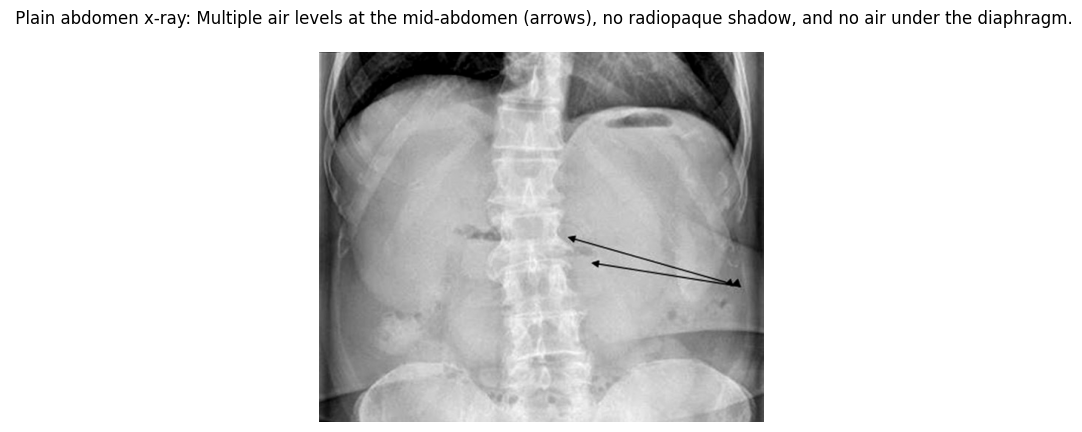

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def show_sample_xray(xray_data):
    """Displays a sample X-ray image with its caption."""
    if not xray_data:
        print("No X-ray images found!")
        return

    img_path, caption = xray_data[0]
    img = Image.open(img_path)

    plt.imshow(img, cmap="gray")  # Medical images are usually grayscale
    plt.axis("off")
    plt.title(caption)
    plt.show()

# Show a sample X-ray image
show_sample_xray(xray_data)


In [3]:
import os
import pandas as pd

# Define the dataset folder
xray_dataset_path = "/content/working_new/train/xray_dataset_NEW"
captions_file = os.path.join(xray_dataset_path, "captions.txt")

# Read the captions file
captions = pd.read_csv(captions_file, sep="\t", names=["image_name", "caption"])

# Add full image paths
captions["image_path"] = captions["image_name"].apply(lambda x: os.path.join(xray_dataset_path, x))

# Show first few rows
captions.head()


,image_name,caption,image_path
0,PMC4917066_amjcaserep-17-301-g001.jpg,Plain abdomen x-ray: Multiple air levels at t...,/content/working_new/train/xray_dataset_NEW/PM...
1,PMC5350332_CRIPE2017-6969787.003.jpg,AP pelvis X-ray obtained 6 weeks from initial...,/content/working_new/train/xray_dataset_NEW/PM...
2,PMC4891922_12891_2016_1099_Fig3_HTML.jpg,X-ray control of calcaneus drilling,/content/working_new/train/xray_dataset_NEW/PM...
3,PMC4239440_PAMJ-18-217-g001.jpg,Free air beneath the diaphragm at abdominal x...,/content/working_new/train/xray_dataset_NEW/PM...
4,PMC4546967_CRIOR2015-301949.003.jpg,X-ray arthrogram showing mild contrast tracki...,/content/working_new/train/xray_dataset_NEW/PM...


In [ ]:
captions.head()

,image_name,caption,image_path
0,PMC4917066_amjcaserep-17-301-g001.jpg,Abdominal CT scan showing pancreatic pseudocyst,/content/working_new/train/xray_dataset_NEW/PM...
1,PMC5350332_CRIPE2017-6969787.003.jpg,CT image of the liver shows air in the hepati...,/content/working_new/train/xray_dataset_NEW/PM...
2,PMC4891922_12891_2016_1099_Fig3_HTML.jpg,Coronal contrast chest CT image showing the t...,/content/working_new/train/xray_dataset_NEW/PM...
3,PMC4239440_PAMJ-18-217-g001.jpg,Osteoid osteoma in the femur. Axial CT scan s...,/content/working_new/train/xray_dataset_NEW/PM...
4,PMC4546967_CRIOR2015-301949.003.jpg,CT spine showing a mass at level of C3 with m...,/content/working_new/train/xray_dataset_NEW/PM...


# **PreProcessing & Cleanning**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
from tqdm import tqdm
import re
import pandas as pd
import os
from PIL import Image
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import CLIPTextModel, CLIPTokenizer
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils.rnn import pad_sequence
from torchvision.utils import make_grid

# Download NLTK resources if not already downloaded
import nltk
try:
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('stopwords')
    nltk.download('wordnet')

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# Caption cleaning and processing functions
def clean_captions(df):
    """
    Cleans and normalizes captions in a DataFrame by lowercasing, removing non-alphabetic characters,
    removing stopwords, lemmatizing, and adding start/end tokens.

    Args:
        df (pandas.DataFrame): DataFrame with a 'caption' column

    Returns:
        pandas.DataFrame: DataFrame with cleaned captions
    """
    cleaned_captions = []

    for caption in df['caption']:
        # Lowercase the text
        caption = caption.lower()

        # Remove non-alphabet characters (except spaces)
        caption = re.sub(r'[^a-z\s]', '', caption)

        # Remove extra spaces
        caption = re.sub(r'\s+', ' ', caption).strip()

        # Tokenize words
        words = caption.split()

        # Remove stopwords & lemmatize
        words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

        # Reconstruct caption with start/end tokens
        cleaned_caption = f"<start> {' '.join(words)} <end>"

        # Update the list
        cleaned_captions.append(cleaned_caption)

    # Create a copy of the df with cleaned captions
    cleaned_df = df.copy()
    cleaned_df['cleaned_caption'] = cleaned_captions

    return cleaned_df

In [ ]:
def prepare_tokenizer_and_sequences(df, caption_col='cleaned_caption'):
    """
    Prepares tokenizer and sequences from captions in a DataFrame.

    Args:
        df (pandas.DataFrame): DataFrame with captions
        caption_col (str): Column name containing captions

    Returns:
        tuple: (tokenizer, df with sequence column, vocab_size, max_length)
    """
    # Collect all captions
    all_captions = df[caption_col].tolist()

    # Create tokenizer with special tokens
    tokenizer = Tokenizer(oov_token="<unk>")
    tokenizer.fit_on_texts(all_captions)

    # Add special tokens if not already present
    word_index = tokenizer.word_index

    # Make sure special tokens are in vocabulary
    special_tokens = ["<pad>", "<start>", "<end>", "<unk>"]
    for token in special_tokens:
        if token not in word_index:
            # Add token to word_index
            word_index[token] = len(word_index) + 1

    # Update tokenizer with special tokens
    tokenizer.word_index = word_index
    tokenizer.index_word = {v: k for k, v in word_index.items()}

    # Final vocabulary size
    vocab_size = len(tokenizer.word_index) + 1

    # Convert captions to sequences
    sequences = tokenizer.texts_to_sequences(all_captions)

    # Find max sequence length
    max_length = max(len(seq) for seq in sequences)

    # Pad sequences
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

    # Add sequence column to DataFrame
    result_df = df.copy()
    result_df['caption_sequence'] = padded_sequences.tolist()

    return tokenizer, result_df, vocab_size, max_length

In [ ]:
def create_embedding_matrix(vocab_size, embedding_dim, tokenizer):
    """
    Creates an embedding matrix for the vocabulary.

    Args:
        vocab_size (int): Size of vocabulary.
        embedding_dim (int): Dimension of embeddings.
        tokenizer (Tokenizer): Keras tokenizer object.

    Returns:
        numpy.ndarray: Embedding matrix.
    """
    # Initialize embedding matrix with random values
    embedding_matrix = np.random.uniform(-0.1, 0.1, size=(vocab_size, embedding_dim))

    # Set padding token to zeros
    if "<pad>" in tokenizer.word_index:
        pad_idx = tokenizer.word_index["<pad>"]
        embedding_matrix[pad_idx] = np.zeros(embedding_dim)

    return embedding_matrix

In [ ]:
def prepare_train_test_data(df, test_size=0.05):
    """
    Splits the DataFrame into training and testing sets.

    Args:
        df (pandas.DataFrame): DataFrame with processed data
        test_size (float): Fraction of data to use for testing

    Returns:
        tuple: (train_df, test_df)
    """
    # Shuffle the DataFrame
    df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Calculate split index
    split_idx = int(len(df) * (1 - test_size))

    # Split into train and test
    train_df = df_shuffled.iloc[:split_idx].reset_index(drop=True)
    test_df = df_shuffled.iloc[split_idx:].reset_index(drop=True)

    return train_df, test_df

In [ ]:
from PIL import Image
import torch
import numpy as np
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# Define transformation for resizing images
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Ensure single channel
    transforms.Resize((128, 128)),  # Resize to fixed shape
    transforms.ToTensor(),  # Convert to tensor [C, H, W]
])

# Custom collate function to handle variable-sized images
def collate_fn(batch):
    paths, seqs = zip(*batch)

    images = []
    for path in paths:
        img = Image.open(path).convert('L')  # Convert to grayscale
        img = transform(img)  # Apply transformations
        images.append(img)

    # Stack images into a single tensor
    images = torch.stack(images)  # Shape: [batch_size, 1, 256, 256]

    # Pad sequences for captions
    seqs = pad_sequence(seqs, batch_first=True, padding_value=0)

    return images, seqs, paths

# Load DataLoader with updated collate function
def load_data_from_dataframe(df, tokenizer, batch_size=16, shuffle=True, num_workers=4):
    image_paths = df['image_path'].tolist()
    caption_sequences = df['caption_sequence'].tolist()

    if not isinstance(caption_sequences[0], torch.Tensor):
        caption_sequences = [torch.tensor(seq) for seq in caption_sequences]

    dataset = [(path, seq) for path, seq in zip(image_paths, caption_sequences)]

    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=num_workers, collate_fn=collate_fn)


### Diffusion Model From Scratch (Approach1)

In [ ]:
class ResolutionHandler(nn.Module):
    """Handles resolution mismatches and processes feature maps with time embeddings."""
    def __init__(self, in_ch, out_ch, curr_res, target_res, time_emb_dim=None):
        super().__init__()
        self.in_ch = in_ch
        self.out_ch = out_ch
        self.curr_res = curr_res
        self.target_res = target_res

        # Time embedding projection
        self.time_mlp = nn.Linear(time_emb_dim, out_ch) if time_emb_dim is not None else None

        # Dynamically set group count for GroupNorm
        self.num_groups = min(8, in_ch // 4)

        # Main processing blocks
        self.norm1 = nn.GroupNorm(self.num_groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.norm2 = nn.GroupNorm(min(8, out_ch // 4), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        # Shortcut connection for residual
        self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

        # Activation function
        self.act = nn.SiLU()

    def forward(self, x, time_emb=None):
        """
        Args:
            x: Input feature map [B, C, H, W]
            time_emb: Time embedding [B, time_emb_dim]
        """
        # Check if input channels match the expected number
        actual_in_ch = x.shape[1]
        if actual_in_ch != self.in_ch:
            # Need to recreate norm1 with the actual input channel count
            num_groups = min(8, actual_in_ch // 4)
            self.norm1 = nn.GroupNorm(num_groups, actual_in_ch).to(x.device)
            self.shortcut = nn.Conv2d(actual_in_ch, self.out_ch, kernel_size=1).to(x.device)

        print(f"ResolutionHandler Input Shape: {x.shape}")  # Debugging output

        # Main branch
        h = self.norm1(x)
        h = self.act(h)
        h = self.conv1(h)

        # Add time embedding if provided
        if time_emb is not None and self.time_mlp is not None:
            time_emb = self.time_mlp(time_emb).unsqueeze(-1).unsqueeze(-1)  # Ensure correct shape
            h = h + time_emb

        h = self.norm2(h)
        h = self.act(h)
        h = self.conv2(h)

        # Handle resolution mismatch if needed
        if self.curr_res != self.target_res:
            h = F.interpolate(h, size=(self.target_res, self.target_res), mode='bilinear', align_corners=False)

        # Apply shortcut (residual connection)
        residual = self.shortcut(x)
        if self.curr_res != self.target_res:
            residual = F.interpolate(residual, size=(self.target_res, self.target_res), mode='bilinear', align_corners=False)

        out = h + residual
        print(f"ResolutionHandler Output Shape: {out.shape}")  # Debugging output

        return out

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPositionEmbeddings(nn.Module):
    """Sinusoidal positional embeddings for time steps."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000., device=device)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class CrossAttention(nn.Module):
    """Cross attention module for conditioning on text embeddings."""
    def __init__(self, dim, context_dim, heads=8, dim_head=64):
        super().__init__()
        inner_dim = dim_head * heads
        self.scale = dim_head ** -0.5
        self.heads = heads

        self.to_q = nn.Linear(dim, inner_dim, bias=False)
        self.to_k = nn.Linear(context_dim, inner_dim, bias=False)
        self.to_v = nn.Linear(context_dim, inner_dim, bias=False)

        self.to_out = nn.Linear(inner_dim, dim)

    def forward(self, x, context):
        h = self.heads

        q = self.to_q(x)
        k = self.to_k(context)
        v = self.to_v(context)

        q, k, v = map(lambda t: t.reshape(t.shape[0], -1, h, t.shape[-1] // h).transpose(1, 2), (q, k, v))

        sim = torch.einsum('bhid,bhjd->bhij', q, k) * self.scale
        attn = sim.softmax(dim=-1)

        out = torch.einsum('bhij,bhjd->bhid', attn, v)
        out = out.transpose(1, 2).reshape(out.shape[0], -1, out.shape[-1] * h)

        return self.to_out(out)

class ResBlock(nn.Module):
    """Residual block with dynamic channel handling to prevent mismatches."""
    def __init__(self, in_channels, out_channels, time_emb_dim=None):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        # Time embedding projection
        self.time_mlp = nn.Linear(time_emb_dim, out_channels) if time_emb_dim is not None else None

        # Calculate appropriate number of groups for normalization
        self.norm1 = nn.GroupNorm(min(8, in_channels // 4), in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.norm2 = nn.GroupNorm(min(8, out_channels // 4), out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        # Skip connection that handles channel differences
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

        self.act = nn.SiLU()

    def forward(self, x, time_emb=None):
        # Check if input channels match what's expected
        actual_channels = x.shape[1]
        if actual_channels != self.in_channels:
            # Dynamically adjust for the actual input channels
            device = x.device
            adjusted_norm = nn.GroupNorm(min(8, actual_channels // 4), actual_channels).to(device)
            adjusted_conv = nn.Conv2d(actual_channels, self.out_channels, kernel_size=3, padding=1).to(device)
            adjusted_skip = nn.Conv2d(actual_channels, self.out_channels, kernel_size=1).to(device)

            # Use the adjusted layers
            h = adjusted_norm(x)
            h = self.act(h)
            h = adjusted_conv(h)

            # Process the rest normally
            if time_emb is not None and self.time_mlp is not None:
                time_emb = self.time_mlp(time_emb).unsqueeze(-1).unsqueeze(-1)
                h = h + time_emb

            h = self.norm2(h)
            h = self.act(h)
            h = self.conv2(h)

            # Apply adjusted skip connection
            return h + adjusted_skip(x)
        else:
            # Standard forward pass when channels match
            h = self.norm1(x)
            h = self.act(h)
            h = self.conv1(h)

            if time_emb is not None and self.time_mlp is not None:
                time_emb = self.time_mlp(time_emb).unsqueeze(-1).unsqueeze(-1)
                h = h + time_emb

            h = self.norm2(h)
            h = self.act(h)
            h = self.conv2(h)

            return h + self.skip(x)

class XrayUNet(nn.Module):
    def __init__(self, in_channels=1, model_channels=64, out_channels=1,
                 channel_mults=(1, 2, 4, 8), num_res_blocks=2, attention_resolutions=(8, 4),
                 dropout=0.1, text_embed_dim=768, image_size=256):
        super().__init__()
        self.in_channels = in_channels
        self.model_channels = model_channels
        self.out_channels = out_channels
        self.channel_mults = channel_mults
        self.time_embed_dim = model_channels * 4
        self.num_res_blocks = num_res_blocks
        self.attention_resolutions = attention_resolutions
        self.dropout_rate = dropout
        self.text_embed_dim = text_embed_dim
        self.image_size = image_size

        # Time embedding
        self.time_embedding = nn.Sequential(
            SinusoidalPositionEmbeddings(model_channels),
            nn.Linear(model_channels, self.time_embed_dim),
            nn.SiLU(),
            nn.Linear(self.time_embed_dim, self.time_embed_dim)
        )

        # Initial convolution
        self.input_block = nn.Conv2d(in_channels, model_channels, kernel_size=3, padding=1)

        # Build U-Net with proper channel tracking
        self._build_model()

    def _build_model(self):
        # Down blocks
        self.down_blocks = nn.ModuleList()

        # Track channels for skip connections
        ch = self.model_channels
        curr_res = self.image_size

        # Store the expected channel dimensions at each level
        self.expected_channels = []

        # Downsampling path
        for level, mult in enumerate(self.channel_mults):
            out_ch = self.model_channels * mult

            for _ in range(self.num_res_blocks):
                self.down_blocks.append(ResBlock(ch, out_ch, time_emb_dim=self.time_embed_dim))
                ch = out_ch
                self.expected_channels.append(ch)

                if curr_res in self.attention_resolutions:
                    self.down_blocks.append(CrossAttention(ch, self.text_embed_dim))

            # Add downsampling if not the last level
            if level < len(self.channel_mults) - 1:
                self.down_blocks.append(nn.Conv2d(ch, ch, kernel_size=3, stride=2, padding=1))
                curr_res //= 2
                self.expected_channels.append(ch)

        # Middle blocks
        self.middle_blocks = nn.ModuleList([
            ResBlock(ch, ch, time_emb_dim=self.time_embed_dim),
            CrossAttention(ch, self.text_embed_dim),
            ResBlock(ch, ch, time_emb_dim=self.time_embed_dim)
        ])

        # Up blocks
        self.up_blocks = nn.ModuleList()
        for level, mult in reversed(list(enumerate(self.channel_mults))):
            out_ch = self.model_channels * mult

            for i in range(self.num_res_blocks + 1):
                # For skip connections, use twice the channels
                skip_ch = self.expected_channels.pop() if self.expected_channels else 0
                in_ch = ch + skip_ch
                self.up_blocks.append(ResBlock(in_ch, out_ch, time_emb_dim=self.time_embed_dim))
                ch = out_ch

                if curr_res in self.attention_resolutions:
                    self.up_blocks.append(CrossAttention(ch, self.text_embed_dim))

            # Add upsampling if not the first level
            if level > 0:
                self.up_blocks.append(nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                    nn.Conv2d(ch, ch, kernel_size=3, padding=1)
                ))
                curr_res *= 2

        # Output
        self.output_blocks = nn.Sequential(
            nn.GroupNorm(min(8, ch // 4), ch),
            nn.SiLU(),
            nn.Dropout(self.dropout_rate),
            nn.Conv2d(ch, self.out_channels, kernel_size=3, padding=1)
        )

    def forward(self, x, time, text_embeds):
        # Process time embedding
        time_emb = self.time_embedding(time)

        # Initial feature extraction
        h = self.input_block(x)

        # Store skip connections
        skips = []

        # Downsampling path
        for module in self.down_blocks:
            if isinstance(module, ResBlock):
                h = module(h, time_emb)
            elif isinstance(module, CrossAttention):
                b, c, height, width = h.shape
                h_flat = h.view(b, c, -1).permute(0, 2, 1)  # [B, H*W, C]
                h_flat = module(h_flat, text_embeds)
                h = h_flat.permute(0, 2, 1).view(b, c, height, width)
            else:
                # Downsampling Conv
                h = module(h)

            # Save skip connection for upsampling path
            skips.append(h)

        # Middle blocks
        for module in self.middle_blocks:
            if isinstance(module, ResBlock):
                h = module(h, time_emb)
            elif isinstance(module, CrossAttention):
                b, c, height, width = h.shape
                h_flat = h.view(b, c, -1).permute(0, 2, 1)
                h_flat = module(h_flat, text_embeds)
                h = h_flat.permute(0, 2, 1).view(b, c, height, width)

        # Upsampling path
        for module in self.up_blocks:
            if isinstance(module, ResBlock):
                # Add skip connection if available
                if skips:
                    skip = skips.pop()
                    # Ensure shapes match for concatenation
                    if h.shape[2:] != skip.shape[2:]:
                        h = F.interpolate(h, size=skip.shape[2:], mode='bilinear', align_corners=False)
                    h = torch.cat([h, skip], dim=1)
                h = module(h, time_emb)
            elif isinstance(module, CrossAttention):
                b, c, height, width = h.shape
                h_flat = h.view(b, c, -1).permute(0, 2, 1)
                h_flat = module(h_flat, text_embeds)
                h = h_flat.permute(0, 2, 1).view(b, c, height, width)
            else:
                # Upsampling module
                h = module(h)

        # Output projection
        return self.output_blocks(h)

In [ ]:
class MedicalTextEncoder(nn.Module):
    """
    Text encoder for medical captions using embedding matrix and GRU.
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, embedding_matrix=None):
        super().__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        if embedding_matrix is not None:
            # Convert numpy array to tensor if it's not already a tensor
            if not isinstance(embedding_matrix, torch.Tensor):
                embedding_matrix = torch.from_numpy(embedding_matrix).float()
            self.embedding.weight.data.copy_(embedding_matrix)

        # GRU layer
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Final projection
        self.proj = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, x):
        # x: [batch_size, seq_len]

        # Get embeddings
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        # Process with GRU
        output, hidden = self.gru(embedded)  # output: [batch_size, seq_len, hidden_dim*2]

        # Project to final dimension
        output = self.proj(output[:, -1, :])  # Use last timestep output

        return output


In [ ]:
class XrayDiffusionModel:
    """Diffusion model for X-ray image generation and caption conditioning."""
    def __init__(self, model, betas=(1e-4, 0.02), n_timesteps=1000, device="cuda"):
        self.model = model.to(device)
        self.device = device
        self.n_timesteps = n_timesteps

        # Define beta schedule
        self.betas = torch.linspace(betas[0], betas[1], n_timesteps).to(device)

        # Compute alphas and related terms
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        # Pre-compute terms for sampling
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1 / self.alphas)

        # For posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = self.betas * (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod)

    def add_noise(self, x_0, t):
        """Forward diffusion process: q(x_t | x_0)"""
        noise = torch.randn_like(x_0)

        # Extract the corresponding alphas for these timesteps
        sqrt_alphas_cumprod_t = self.sqrt_alphas_cumprod[t].reshape(-1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1)

        # Return noisy image
        return sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise, noise

    def sample_timesteps(self, n):
        """Sample timesteps uniformly for training"""
        return torch.randint(low=0, high=self.n_timesteps, size=(n,), device=self.device)

    def train_step(self, x_0, text_embeds, optimizer):
        """Training step"""
        optimizer.zero_grad()

        batch_size = x_0.shape[0]
        t = self.sample_timesteps(batch_size)

        # Add noise to images
        x_t, noise = self.add_noise(x_0, t)

        # Predict noise
        predicted_noise = self.model(x_t, t, text_embeds)

        # Compute loss
        loss = F.mse_loss(predicted_noise, noise)

        # Backpropagation
        loss.backward()
        optimizer.step()

        return loss.item()

    def compute_loss(self, x_0, text_embeds):
        """Compute loss for validation without backpropagation"""
        batch_size = x_0.shape[0]
        t = self.sample_timesteps(batch_size)

        # Add noise to images
        x_t, noise = self.add_noise(x_0, t)

        # Predict noise
        predicted_noise = self.model(x_t, t, text_embeds)

        # Compute loss
        loss = F.mse_loss(predicted_noise, noise)

        return loss.item()

    @torch.no_grad()
    def sample(self, shape, text_embeds, cfg_scale=7.5, num_sampling_steps=50):
        """Generate X-ray images using DDIM sampling with classifier-free guidance"""
        device = self.device
        batch_size = shape[0]

        # Start from random noise
        img = torch.randn(shape, device=device)

        # Create an unconditional embedding (empty text)
        uncond_embeds = torch.zeros_like(text_embeds)

        # Set timesteps for sampling (evenly spaced)
        timesteps = torch.linspace(self.n_timesteps - 1, 0, num_sampling_steps, dtype=torch.long, device=device)

        for i, t in enumerate(tqdm(timesteps)):
            # Expand the timestep to match batch size
            t_batch = torch.full((batch_size,), t, device=device, dtype=torch.long)

            # Predict noise with conditional embedding
            noise_pred_cond = self.model(img, t_batch, text_embeds)

            # Predict noise with unconditional embedding for classifier-free guidance
            noise_pred_uncond = self.model(img, t_batch, uncond_embeds)

            # Perform classifier-free guidance
            noise_pred = noise_pred_uncond + cfg_scale * (noise_pred_cond - noise_pred_uncond)

            # DDIM sampling formula
            alpha = self.alphas_cumprod[t]
            alpha_prev = self.alphas_cumprod[t-1] if t > 0 else torch.tensor(1.0).to(device)

            sigma = 0  # Can be tuned for stochastic sampling

            # The predicted x_0
            pred_original_sample = (img - torch.sqrt(1 - alpha).reshape(-1, 1, 1, 1) * noise_pred) / torch.sqrt(alpha).reshape(-1, 1, 1, 1)

            # Direction pointing to x_t
            dir_xt = torch.sqrt(1 - alpha_prev - sigma**2).reshape(-1, 1, 1, 1) * noise_pred

            # Random noise for stochasticity
            noise = torch.zeros_like(img) if sigma == 0 else torch.randn_like(img) * sigma

            # Compute x_{t-1}
            img = torch.sqrt(alpha_prev).reshape(-1, 1, 1, 1) * pred_original_sample + dir_xt + noise

        # Rescale to [0, 1]
        img = (img.clamp(-1, 1) + 1) / 2

        return img

In [ ]:
def setup_medical_text_embeddings(vocab_size, tokenizer=None, embedding_dim=256, hidden_dim=512, device="cuda"):
    """
    Sets up a text encoder for the caption embeddings.

    Args:
        vocab_size (int): Size of vocabulary
        tokenizer: Tokenizer for creating embedding matrix
        embedding_dim (int): Dimension of word embeddings
        hidden_dim (int): Dimension of hidden state in GRU
        device (str): Device to use

    Returns:
        tuple: (embedding_matrix, text_encoder)
    """
    # Create embedding matrix
    if tokenizer:
        embedding_matrix = create_embedding_matrix(vocab_size, embedding_dim, tokenizer)
        embedding_tensor = torch.from_numpy(embedding_matrix).float()  # Ensure it's a float tensor
    else:
        embedding_matrix = None
        embedding_tensor = None

    # Create text encoder
    text_encoder = MedicalTextEncoder(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        embedding_matrix=embedding_matrix  # Pass numpy array, not tensor
    ).to(device)

    return embedding_matrix, text_encoder

##### Training Our Own VAE Model

In [ ]:
class XrayVAE(nn.Module):
    """Variational Autoencoder for X-ray images."""
    def __init__(self, in_channels=1, latent_dim=128, hidden_dims=None):
        super().__init__()
        self.latent_dim = latent_dim

        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256]

        # Build encoder
        modules = []

        # Input channels -> first hidden dim
        modules.append(
            nn.Sequential(
                nn.Conv2d(in_channels, hidden_dims[0], kernel_size=3, stride=2, padding=1),
                nn.BatchNorm2d(hidden_dims[0]),
                nn.LeakyReLU()
            )
        )

        # Hidden layers
        for i in range(len(hidden_dims) - 1):
            modules.append(
                nn.Sequential(
                    nn.Conv2d(hidden_dims[i], hidden_dims[i + 1], kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(hidden_dims[i + 1]),
                    nn.LeakyReLU()
                )
            )

        self.encoder = nn.Sequential(*modules)

        # Calculate output dimensions of encoder
        # For 128x128 input with 4 layers of stride 2: 128 -> 64 -> 32 -> 16 -> 8
        self.encoder_output_dim = hidden_dims[-1] * (128 // (2**len(hidden_dims))) * (128 // (2**len(hidden_dims)))

        # Latent space
        self.fc_mu = nn.Linear(self.encoder_output_dim, latent_dim)
        self.fc_var = nn.Linear(self.encoder_output_dim, latent_dim)
        self.fc_decoder_input = nn.Linear(latent_dim, self.encoder_output_dim)

        # Build decoder
        modules = []

        # Initial size
        self.decoder_input_size = 128 // (2**len(hidden_dims))

        # Hidden layers
        hidden_dims.reverse()

        for i in range(len(hidden_dims) - 1):
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(hidden_dims[i], hidden_dims[i + 1],
                                      kernel_size=3, stride=2, padding=1, output_padding=1),
                    nn.BatchNorm2d(hidden_dims[i + 1]),
                    nn.LeakyReLU()
                )
            )

        # Output layer
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(hidden_dims[-1], hidden_dims[-1],
                                  kernel_size=3, stride=2, padding=1, output_padding=1),
                nn.BatchNorm2d(hidden_dims[-1]),
                nn.LeakyReLU(),
                nn.Conv2d(hidden_dims[-1], out_channels=in_channels, kernel_size=3, padding=1),
                nn.Sigmoid()  # Output normalized between 0 and 1
            )
        )

        hidden_dims.reverse()  # Restore hidden_dims order
        self.decoder = nn.Sequential(*modules)

    def encode(self, x):
        """Encode input into latent representation."""
        x = self.encoder(x)
        x = torch.flatten(x, start_dim=1)

        # Get mu and log_var for latent distribution
        mu = self.fc_mu(x)
        log_var = self.fc_var(x)

        return mu, log_var

    def decode(self, z):
        """Decode latent representation back to image."""
        z = self.fc_decoder_input(z)
        z = z.view(-1, self.encoder_output_dim // (self.decoder_input_size**2),
                  self.decoder_input_size, self.decoder_input_size)

        return self.decoder(z)

    def reparameterize(self, mu, log_var):
        """Reparameterization trick."""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def forward(self, x):
        """Forward pass through the VAE."""
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_reconstructed = self.decode(z)

        return x_reconstructed, mu, log_var

def vae_loss_function(recon_x, x, mu, log_var, kld_weight=0.005):
    """
    VAE loss function combining reconstruction loss and KL divergence.

    Args:
        recon_x: Reconstructed input
        x: Original input
        mu: Mean of latent distribution
        log_var: Log variance of latent distribution
        kld_weight: Weight for KL divergence term

    Returns:
        tuple: (loss, reconstruction_loss, kld_loss)
    """
    # Reconstruction loss - Mean Squared Error
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # KL divergence loss
    kld_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Total loss
    loss = recon_loss + kld_weight * kld_loss

    return loss, recon_loss, kld_loss

def train_xray_vae(
    train_df,
    test_df,
    epochs=50,
    batch_size=16,
    learning_rate=1e-4,
    device="cuda",
    image_size=128,
    latent_dim=128,
    log_dir="runs/xray_vae",
    save_dir="models/xray_vae",
    validation_interval=5
):
    """
    Train the VAE model on X-ray data with TensorBoard logging.

    Args:
        train_df (pandas.DataFrame): Training data with image paths
        test_df (pandas.DataFrame): Testing data with image paths
        epochs (int): Number of epochs to train
        batch_size (int): Batch size
        learning_rate (float): Learning rate
        device (str): Device to use
        image_size (int): Size of images
        latent_dim (int): Dimensionality of the latent space
        log_dir (str): Directory for TensorBoard logs
        save_dir (str): Directory to save model checkpoints
        validation_interval (int): Epochs between validation runs
    """
    # Create directories if they don't exist
    os.makedirs(log_dir, exist_ok=True)
    os.makedirs(save_dir, exist_ok=True)

    # Initialize TensorBoard writer
    writer = SummaryWriter(log_dir)

    # Define transformation for resizing images for VAE
    vae_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])

    # Custom collate function for VAE training (images only)
    def vae_collate_fn(batch):
        paths, _ = zip(*batch)

        images = []
        for path in paths:
            img = Image.open(path).convert('L')
            img = vae_transform(img)
            images.append(img)

        images = torch.stack(images)
        return images, paths

    # Load data for VAE training (we only need images, not captions)
    def load_vae_data(df, batch_size=16, shuffle=True, num_workers=4):
        image_paths = df['image_path'].tolist()
        # Use dummy sequences as we don't need them for VAE
        dummy_sequences = [torch.tensor([0]) for _ in range(len(image_paths))]

        dataset = [(path, seq) for path, seq in zip(image_paths, dummy_sequences)]

        return DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            collate_fn=vae_collate_fn
        )

    # Create dataloaders
    train_loader = load_vae_data(train_df, batch_size=batch_size, shuffle=True)
    test_loader = load_vae_data(test_df, batch_size=batch_size, shuffle=False)

    # Initialize VAE model
    vae = XrayVAE(
        in_channels=1,
        latent_dim=latent_dim,
        hidden_dims=[32, 64, 128, 256]
    ).to(device)

    # Setup optimizer
    optimizer = torch.optim.Adam(vae.parameters(), lr=learning_rate)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )

    # Track best validation loss
    best_val_loss = float('inf')

    # Training loop
    for epoch in range(epochs):
        vae.train()

        # Initialize loss trackers
        train_loss = 0.0
        train_recon_loss = 0.0
        train_kld_loss = 0.0
        batch_count = 0

        # Progress bar for training
        train_pbar = tqdm(train_loader, desc=f"VAE Epoch {epoch+1}/{epochs}")

        for images, _ in train_pbar:
            # Move data to device
            images = images.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            reconstructed, mu, log_var = vae(images)

            # Compute loss
            loss, recon_loss, kld_loss = vae_loss_function(reconstructed, images, mu, log_var)

            # Backward pass
            loss.backward()

            # Clip gradients
            torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)

            # Update parameters
            optimizer.step()

            # Update loss trackers
            train_loss += loss.item()
            train_recon_loss += recon_loss.item()
            train_kld_loss += kld_loss.item()
            batch_count += 1

            # Update progress bar
            train_pbar.set_postfix(loss=loss.item() / images.size(0))

        # Calculate average training losses
        avg_train_loss = train_loss / batch_count if batch_count > 0 else 0
        avg_train_recon_loss = train_recon_loss / batch_count if batch_count > 0 else 0
        avg_train_kld_loss = train_kld_loss / batch_count if batch_count > 0 else 0

        # Log training losses
        writer.add_scalar('VAE/Loss/train', avg_train_loss, epoch)
        writer.add_scalar('VAE/ReconLoss/train', avg_train_recon_loss, epoch)
        writer.add_scalar('VAE/KLDLoss/train', avg_train_kld_loss, epoch)

        print(f"VAE Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.6f}")

        # Validation
        if (epoch + 1) % validation_interval == 0:
            vae.eval()

            val_loss = 0.0
            val_recon_loss = 0.0
            val_kld_loss = 0.0
            val_batch_count = 0

            # Progress bar for validation
            val_pbar = tqdm(test_loader, desc="VAE Validation")

            with torch.no_grad():
                for images, _ in val_pbar:
                    # Move data to device
                    images = images.to(device)

                    # Forward pass
                    reconstructed, mu, log_var = vae(images)

                    # Compute loss
                    loss, recon_loss, kld_loss = vae_loss_function(reconstructed, images, mu, log_var)

                    # Update loss trackers
                    val_loss += loss.item()
                    val_recon_loss += recon_loss.item()
                    val_kld_loss += kld_loss.item()
                    val_batch_count += 1

                    # Update progress bar
                    val_pbar.set_postfix(loss=loss.item() / images.size(0))

                # Calculate average validation losses
                avg_val_loss = val_loss / val_batch_count if val_batch_count > 0 else 0
                avg_val_recon_loss = val_recon_loss / val_batch_count if val_batch_count > 0 else 0
                avg_val_kld_loss = val_kld_loss / val_batch_count if val_batch_count > 0 else 0

                # Log validation losses
                writer.add_scalar('VAE/Loss/validation', avg_val_loss, epoch)
                writer.add_scalar('VAE/ReconLoss/validation', avg_val_recon_loss, epoch)
                writer.add_scalar('VAE/KLDLoss/validation', avg_val_kld_loss, epoch)

                print(f"VAE Validation Loss: {avg_val_loss:.6f}")

                # Update learning rate scheduler
                scheduler.step(avg_val_loss)

                # Save model if it has the best validation loss
                if avg_val_loss < best_val_loss:
                    best_val_loss = avg_val_loss

                    # Save model
                    torch.save(vae.state_dict(), os.path.join(save_dir, 'best_vae_model.pth'))
                    print(f"Saved best VAE model with validation loss: {best_val_loss:.6f}")

                # Generate reconstructions for visualization
                try:
                    # Get a sample batch
                    sample_images, _ = next(iter(test_loader))
                    sample_images = sample_images.to(device)

                    # Generate reconstructions
                    reconstructed, _, _ = vae(sample_images)

                    # Visualize original and reconstructed images
                    comparison = torch.cat([
                        sample_images[:8],
                        reconstructed[:8]
                    ])
                    grid = make_grid(comparison, nrow=8, normalize=True)
                    writer.add_image('VAE/Original_vs_Reconstructed', grid, epoch)

                    # Generate random samples from latent space
                    random_z = torch.randn(8, latent_dim).to(device)
                    generated = vae.decode(random_z)
                    grid = make_grid(generated, nrow=4, normalize=True)
                    writer.add_image('VAE/Generated_Samples', grid, epoch)

                except Exception as e:
                    print(f"Error generating VAE samples: {e}")

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            checkpoint_path = os.path.join(save_dir, f'vae_checkpoint_epoch_{epoch+1}.pth')
            torch.save({
                'epoch': epoch,
                'model_state_dict': vae.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'loss': avg_train_loss,
                'best_val_loss': best_val_loss
            }, checkpoint_path)
            print(f"Saved VAE checkpoint to {checkpoint_path}")

    # Save final model
    torch.save(vae.state_dict(), os.path.join(save_dir, 'final_vae_model.pth'))
    print(f"Saved final VAE model to {save_dir}/final_vae_model.pth")

    # Close TensorBoard writer
    writer.close()

    return vae

def encode_images_with_vae(vae, data_loader, device):
    """
    Encode images using the trained VAE.

    Args:
        vae (XrayVAE): Trained VAE model
        data_loader (DataLoader): DataLoader containing images to encode
        device (str): Device for computation

    Returns:
        tuple: (encodings, image_paths)
    """
    vae.eval()
    encodings = []
    all_paths = []

    with torch.no_grad():
        for images, paths in tqdm(data_loader, desc="Encoding images"):
            images = images.to(device)
            mu, _ = vae.encode(images)
            encodings.append(mu.cpu().numpy())
            all_paths.extend(paths)

    # Concatenate all encodings
    encodings = np.concatenate(encodings, axis=0)

    return encodings, all_paths

class MixedEncoderDiffusion(nn.Module):
    """
    Modified diffusion model that can use VAE encodings along with text embeddings.
    """
    def __init__(self, unet_model, text_embed_dim, vae_embed_dim=None):
        super().__init__()
        self.unet = unet_model

        # If VAE embeddings are provided, create a projection layer
        self.use_vae = vae_embed_dim is not None
        if self.use_vae:
            self.vae_projection = nn.Linear(vae_embed_dim, text_embed_dim)

    def forward(self, x, t, text_embeds, vae_embeds=None):
        # If VAE embeddings are provided, project and combine with text embeddings
        if vae_embeds is not None and self.use_vae:
            vae_projected = self.vae_projection(vae_embeds)
            # Simple addition for combining embeddings
            combined_embeds = text_embeds + vae_projected
            return self.unet(x, t, combined_embeds)
        else:
            # Standard forward pass with just text embeddings
            return self.unet(x, t, text_embeds)

In [ ]:
# Fix for the missing load_vae_data function and completion of the code

def load_vae_data(df, batch_size=16, shuffle=True, num_workers=4):
    """
    Load data for VAE training (images only, not captions).

    Args:
        df (pandas.DataFrame): DataFrame containing image paths
        batch_size (int): Batch size
        shuffle (bool): Whether to shuffle the data
        num_workers (int): Number of workers for data loading

    Returns:
        DataLoader: DataLoader for VAE training
    """
    image_paths = df['image_path'].tolist()
    # Use dummy sequences as we don't need them for VAE
    dummy_sequences = [torch.tensor([0]) for _ in range(len(image_paths))]

    dataset = [(path, seq) for path, seq in zip(image_paths, dummy_sequences)]

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=vae_collate_fn
    )

# Custom collate function for VAE training (images only)
def vae_collate_fn(batch):
    paths, _ = zip(*batch)

    images = []
    for path in paths:
        img = Image.open(path).convert('L')
        img = vae_transform(img)
        images.append(img)

    images = torch.stack(images)
    return images, paths

# Define transformation for resizing images for VAE
vae_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),  # Default size, will be overridden if needed
    transforms.ToTensor(),
])

#### run the train function

In [ ]:
# Main function to run the training
if __name__ == "__main__":
    # Set device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Load raw data
    # data_dir = "/content/working_new/train/xray_dataset_NEW"
    # caption_file = "/content/working_new/train/xray_dataset_NEW"

    # Load CSV with 'image_id' and 'caption' columns
    # You'll need to uncomment and complete this part with your actual data loading
    # captions = pd.read_csv(caption_file)

    # Add image paths
    # captions['image_path'] = captions['image_id'].apply(lambda x: os.path.join(data_dir, f"{x}.png"))

    # Process captions
    print("Cleaning captions...")
    captions = clean_captions(captions)

    # Create tokenizer and sequences
    print("Tokenizing captions...")
    tokenizer, processed_df, vocab_size, max_length = prepare_tokenizer_and_sequences(captions)
    print(f"Vocabulary size: {vocab_size}, Max sequence length: {max_length}")

    # Split data
    train_df, test_df = prepare_train_test_data(processed_df, test_size=0.05)
    print(f"Training set: {len(train_df)} samples, Test set: {len(test_df)} samples")

    # Set parameters
    image_size = 128
    batch_size = 4
    latent_dim = 128  # VAE latent dimension
    epochs = 5
    vae_epochs = 30  # VAE training epochs
    learning_rate = 1e-4
    log_dir = "runs/xray_models"
    vae_log_dir = f"{log_dir}/vae"
    diffusion_log_dir = f"{log_dir}/diffusion"
    save_dir = "models/xray_models"
    vae_save_dir = f"{save_dir}/vae"
    diffusion_save_dir = f"{save_dir}/diffusion"

    # Create directories for logs and models if they don't exist
    os.makedirs(vae_log_dir, exist_ok=True)
    os.makedirs(vae_save_dir, exist_ok=True)
    os.makedirs(diffusion_log_dir, exist_ok=True)
    os.makedirs(diffusion_save_dir, exist_ok=True)

    # First, train the VAE
    print("Starting VAE training...")
    vae = train_xray_vae(
        train_df=train_df,
        test_df=test_df,
        epochs=vae_epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        device=device,
        image_size=image_size,
        latent_dim=latent_dim,
        log_dir=vae_log_dir,
        save_dir=vae_save_dir
    )
    print("VAE training completed!")

    # Load the best VAE model
    best_vae_path = os.path.join(vae_save_dir, 'best_vae_model.pth')
    if os.path.exists(best_vae_path):
        vae.load_state_dict(torch.load(best_vae_path))
        print(f"Loaded best VAE model from {best_vae_path}")

    # Encode training and testing images with VAE
    print("Encoding images with VAE...")
    # Create data loaders for VAE encoding
    vae_train_loader = load_vae_data(train_df, batch_size=batch_size, shuffle=False)
    vae_test_loader = load_vae_data(test_df, batch_size=batch_size, shuffle=False)

    # Encode images
    train_encodings, train_paths = encode_images_with_vae(vae, vae_train_loader, device)
    test_encodings, test_paths = encode_images_with_vae(vae, vae_test_loader, device)

    # Create mapping from image path to VAE encoding
    train_encoding_map = {path: enc for path, enc in zip(train_paths, train_encodings)}
    test_encoding_map = {path: enc for path, enc in zip(test_paths, test_encodings)}

    # Save VAE encodings
    np.save(os.path.join(vae_save_dir, 'train_encodings.npy'), train_encodings)
    np.save(os.path.join(vae_save_dir, 'test_encodings.npy'), test_encodings)
    with open(os.path.join(vae_save_dir, 'train_paths.txt'), 'w') as f:
        for path in train_paths:
            f.write(f"{path}\n")
    with open(os.path.join(vae_save_dir, 'test_paths.txt'), 'w') as f:
        for path in test_paths:
            f.write(f"{path}\n")

    print("VAE encodings saved!")

    # Now train the diffusion model with text embeddings
    print("Starting diffusion model training...")
    # Train the model - pass tokenizer as an argument
    diffusion_model, text_encoder = train_improved_xray_diffusion(
        train_df=train_df,
        test_df=test_df,
        tokenizer=tokenizer,  # Pass the tokenizer
        vocab_size=vocab_size,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        device=device,
        image_size=image_size,
        log_dir=diffusion_log_dir,
        save_dir=diffusion_save_dir
    )

    print("Diffusion model training completed!")

    # Save final models
    torch.save(diffusion_model.model.state_dict(), f"{diffusion_save_dir}/final_diffusion_model.pt")
    torch.save(text_encoder.state_dict(), f"{diffusion_save_dir}/final_text_encoder.pt")

    # Create and save mixed encoder diffusion model that can use both text and VAE embeddings
    mixed_encoder = MixedEncoderDiffusion(
        diffusion_model.model,
        text_embed_dim=512,  # Match the hidden_dim from text encoder
        vae_embed_dim=latent_dim  # VAE latent dimension
    )
    torch.save(mixed_encoder.state_dict(), f"{save_dir}/final_mixed_encoder_diffusion.pt")

    # Save tokenizer
    import pickle
    with open(f"{save_dir}/tokenizer.pkl", "wb") as f:
        pickle.dump(tokenizer, f)

    print(f"All models and tokenizer saved to {save_dir}")
    print("Training pipeline completed successfully!")

Using device: cuda
Cleaning captions...
Tokenizing captions...
Vocabulary size: 5841, Max sequence length: 136
Training set: 5146 samples, Test set: 271 samples
Starting VAE training...


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
VAE Epoch 1/30: 100%|██████████| 1287/1287 [00:27<00:00, 46.82it/s, loss=168]


VAE Epoch 1/30 - Train Loss: 1423.467848


VAE Epoch 2/30: 100%|██████████| 1287/1287 [00:25<00:00, 51.18it/s, loss=227]


VAE Epoch 2/30 - Train Loss: 800.097944


...

Epoch 5/5 - Train Loss: 0.012698


Validation: 100%|██████████| 68/68 [00:06<00:00, 10.53it/s, loss=0.00208]


Validation Loss: 0.012614
Saved best model with validation loss: 0.012614


100%|██████████| 20/20 [00:03<00:00,  6.08it/s]


Epoch 5/5 - Train Loss: 0.012698 - Best Val Loss so far: 0.012614 - Current Val Loss: 0.012614 (this epoch)
Training completed. Best validation loss: 0.012614
Diffusion model training completed!
All models and tokenizer saved to models/xray_models
Training pipeline completed successfully!


#### Inference Function

In [ ]:
import torch
import pickle
import os
from PIL import Image
import numpy as np
from diffusers import AutoencoderKL, DDIMScheduler, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer

class XRayDiffusionGenerator:
    def __init__(self, model_path, vae_path=None):
        """
        Initialize the X-ray diffusion image generator.

        Args:
            model_path: Path to the directory containing the model files
            vae_path: Optional separate path to VAE model
        """
        self.model_path = model_path
        self.vae_path = vae_path if vae_path else model_path
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Using device: {self.device}")

        # Load the tokenizer
        try:
            print("Loading tokenizer...")
            tokenizer_path = os.path.join(model_path, "tokenizer.pkl")
            if os.path.exists(tokenizer_path):
                with open(tokenizer_path, "rb") as f:
                    self.custom_tokenizer = pickle.load(f)
                print(f"Custom tokenizer loaded successfully: {type(self.custom_tokenizer)}")

                # Check if the custom tokenizer has encode method
                if hasattr(self.custom_tokenizer, 'encode'):
                    print("Custom tokenizer has encode method")
                else:
                    print("Custom tokenizer doesn't have encode method")

                # Also load a standard CLIP tokenizer as fallback
                self.clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
            else:
                print("Tokenizer not found, using default CLIP tokenizer")
                self.custom_tokenizer = None
                self.clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")
        except Exception as e:
            print(f"Error loading tokenizer: {e}")
            print("Falling back to default CLIP tokenizer")
            self.custom_tokenizer = None
            self.clip_tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-large-patch14")

        # Load the text encoder - first initialize the model architecture
        print("Loading text encoder...")
        self.text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-large-patch14")

        # Then try to load weights from available files
        try:
            text_encoder_path = os.path.join(model_path, "final_text_encoder.pth")
            if os.path.exists(text_encoder_path):
                state_dict = torch.load(text_encoder_path, map_location=self.device)
                # Check if state_dict is actually a model or just weights
                if hasattr(state_dict, 'state_dict'):
                    self.text_encoder.load_state_dict(state_dict.state_dict())
                else:
                    self.text_encoder.load_state_dict(state_dict)
                print(f"Loaded text encoder from {text_encoder_path}")
            else:
                # Check for mixed encoder model
                mixed_encoder_path = os.path.join(model_path, "final_mixed_encoder_diffusion.pt")
                if os.path.exists(mixed_encoder_path):
                    print(f"Found mixed encoder model at {mixed_encoder_path}")
                    print("Will attempt to extract text encoder weights from mixed model")
                    # We'll attempt to load these later if needed
                else:
                    print("No custom text encoder weights found, using pretrained weights")
        except Exception as e:
            print(f"Error loading text encoder weights: {e}")
            print("Using pretrained text encoder weights")

        # Load UNet model architecture
        print("Loading UNet model...")
        try:
            self.unet = UNet2DConditionModel.from_pretrained(
                "CompVis/stable-diffusion-v1-4",
                subfolder="unet"
            )
        except Exception as e:
            print(f"Error loading UNet architecture: {e}")
            raise

        # Then load UNet weights if available
        try:
            unet_path = os.path.join(model_path, "final_unet_model.pth")
            if os.path.exists(unet_path):
                state_dict = torch.load(unet_path, map_location=self.device)
                # Check if state_dict is actually a model
                if hasattr(state_dict, 'state_dict'):
                    self.unet.load_state_dict(state_dict.state_dict(), strict=False)
                else:
                    self.unet.load_state_dict(state_dict, strict=False)
                print(f"Loaded UNet from {unet_path}")
            elif os.path.exists(os.path.join(model_path, "best_unet_model.pth")):
                unet_path = os.path.join(model_path, "best_unet_model.pth")
                state_dict = torch.load(unet_path, map_location=self.device)
                self.unet.load_state_dict(state_dict, strict=False)
                print(f"Loaded UNet from {unet_path}")
            elif os.path.exists(os.path.join(model_path, "final_diffusion_model.pt")):
                diffusion_path = os.path.join(model_path, "final_diffusion_model.pt")
                print(f"Attempting to load UNet from {diffusion_path}")
                state_dict = torch.load(diffusion_path, map_location=self.device)
                if hasattr(state_dict, 'state_dict'):
                    self.unet.load_state_dict(state_dict.state_dict(), strict=False)
                else:
                    self.unet.load_state_dict(state_dict, strict=False)
                print(f"Loaded UNet weights from {diffusion_path} with strict=False")
            else:
                print("No custom UNet weights found, using pretrained weights")
        except Exception as e:
            print(f"Warning: Error loading UNet weights: {e}")
            print("Using pretrained UNet weights")

        # Load the VAE model
        try:
            print("Setting up VAE model...")
            # First load the architecture
            self.vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae")

            # Then try to load custom weights if available
            vae_model_path = os.path.join(self.vae_path, "vae", "final_vae_model.pth")
            if os.path.exists(vae_model_path):
                print(f"Loading VAE weights from {vae_model_path}")
                state_dict = torch.load(vae_model_path, map_location=self.device)
                if hasattr(state_dict, 'state_dict'):
                    self.vae.load_state_dict(state_dict.state_dict(), strict=False)
                else:
                    self.vae.load_state_dict(state_dict, strict=False)
                print("Custom VAE model loaded successfully")
            else:
                print("No custom VAE model found, using pretrained weights")
        except Exception as e:
            print(f"Error loading VAE model: {e}")
            raise

        # Set up the noise scheduler
        self.scheduler = DDIMScheduler(
            beta_start=0.00085,
            beta_end=0.012,
            beta_schedule="scaled_linear",
            num_train_timesteps=1000,
            clip_sample=False,
            set_alpha_to_one=False,
            steps_offset=1,
        )
        print("Scheduler initialized")

        # Move models to device
        self.text_encoder = self.text_encoder.to(self.device)
        self.unet = self.unet.to(self.device)
        self.vae = self.vae.to(self.device)

        # Set models to evaluation mode
        self.text_encoder.eval()
        self.unet.eval()
        self.vae.eval()
        print("Models moved to device and set to eval mode")

    def tokenize_text(self, text):
        """
        Tokenize text using either the custom tokenizer or fallback to CLIP tokenizer.

        Args:
            text: The text to tokenize

        Returns:
            Dictionary with input_ids tensor
        """
        if self.custom_tokenizer is not None:
            print("Using custom tokenizer")
            # Try different methods of the custom tokenizer
            try:
                if hasattr(self.custom_tokenizer, 'encode'):
                    # Some tokenizers have encode method
                    tokens = self.custom_tokenizer.encode(text)
                    # Convert to tensor and add batch dimension
                    if isinstance(tokens, list):
                        input_ids = torch.tensor([tokens], dtype=torch.long)
                    else:
                        input_ids = tokens.unsqueeze(0) if hasattr(tokens, 'unsqueeze') else torch.tensor([tokens], dtype=torch.long)

                    return {"input_ids": input_ids}
                elif hasattr(self.custom_tokenizer, 'tokenize'):
                    # Some tokenizers have tokenize method
                    tokens = self.custom_tokenizer.tokenize(text)
                    # Convert tokens to ids if necessary
                    if hasattr(self.custom_tokenizer, 'convert_tokens_to_ids'):
                        token_ids = self.custom_tokenizer.convert_tokens_to_ids(tokens)
                    else:
                        # If no conversion method, assume tokens are already ids
                        token_ids = tokens

                    # Pad to max length of 77 (standard for CLIP)
                    if len(token_ids) < 77:
                        token_ids = token_ids + [0] * (77 - len(token_ids))
                    else:
                        token_ids = token_ids[:77]

                    input_ids = torch.tensor([token_ids], dtype=torch.long)
                    return {"input_ids": input_ids}
                else:
                    print("Custom tokenizer doesn't have recognized methods, falling back to CLIP")
                    return self.clip_tokenizer(text, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
            except Exception as e:
                print(f"Error using custom tokenizer: {e}")
                print("Falling back to CLIP tokenizer")
                return self.clip_tokenizer(text, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
        else:
            print("Using CLIP tokenizer")
            return self.clip_tokenizer(text, padding="max_length", max_length=77, truncation=True, return_tensors="pt")

    @torch.no_grad()
    def generate_image(self, prompt, negative_prompt="", height=512, width=512, num_inference_steps=50, guidance_scale=7.5, seed=None):
        """
        Generate an X-ray image from a text prompt.

        Args:
            prompt: Text description of the X-ray to generate
            negative_prompt: Text to guide what should not appear in the image
            height: Height of the generated image
            width: Width of the generated image
            num_inference_steps: Number of denoising steps
            guidance_scale: Scale for classifier-free guidance
            seed: Random seed for reproducibility

        Returns:
            PIL Image: Generated X-ray image
        """
        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)
            print(f"Using seed: {seed}")

        print(f"Generating X-ray with prompt: '{prompt}'")

        # Encode the prompt using the modified tokenize_text method
        text_input = self.tokenize_text(prompt)
        text_embeddings = self.text_encoder(text_input.input_ids.to(self.device))[0]

        # Encode the negative prompt
        uncond_input = self.tokenize_text(negative_prompt)
        uncond_embeddings = self.text_encoder(uncond_input.input_ids.to(self.device))[0]

        # Concatenate embeddings for classifier-free guidance
        text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

        # Initialize random noise
        latents = torch.randn(
            (1, self.unet.config.in_channels, height // 8, width // 8),
            device=self.device
        )

        # Set up the scheduler
        self.scheduler.set_timesteps(num_inference_steps)
        latents = latents * self.scheduler.init_noise_sigma

        # Denoising loop
        print(f"Running diffusion process with {num_inference_steps} steps")
        for i, t in enumerate(self.scheduler.timesteps):
            # Progress indicator
            if i % 10 == 0:
                print(f"Step {i}/{len(self.scheduler.timesteps)}")

            # Expand latents for classifier-free guidance
            latent_model_input = torch.cat([latents] * 2)
            latent_model_input = self.scheduler.scale_model_input(latent_model_input, t)

            # Predict noise using standard UNet forward
            noise_pred = self.unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample

            # Perform guidance
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

            # Compute the previous noisy sample
            latents = self.scheduler.step(noise_pred, t, latents).prev_sample

        # Decode the latents to image
        print("Decoding latents to image")
        latents = 1 / 0.18215 * latents
        image = self.vae.decode(latents).sample

        # Convert to PIL image
        image = (image / 2 + 0.5).clamp(0, 1)
        image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
        image = (image * 255).round().astype("uint8")[0]
        print("Image generation complete")
        return Image.fromarray(image)

def generate_xray_from_text(prompt,
                           model_path="/content/models/xray_models/diffusion/",
                           vae_path="/content/models/xray_models/",
                           negative_prompt="blurry, low quality, distorted",
                           height=512, width=512,
                           num_inference_steps=50,
                           guidance_scale=7.5,
                           seed=None):
    """
    Function to generate X-ray images from text prompt using the loaded model.

    Args:
        prompt: Text description of the X-ray to generate
        model_path: Path to the model directory
        vae_path: Path to the VAE model directory
        negative_prompt: What should not appear in the image
        height: Height of the output image
        width: Width of the output image
        num_inference_steps: Number of denoising steps
        guidance_scale: Scale for classifier-free guidance
        seed: Random seed for reproducibility

    Returns:
        PIL Image: Generated X-ray image
    """
    # Initialize the generator
    generator = XRayDiffusionGenerator(model_path, vae_path)

    # Generate the image
    image = generator.generate_image(
        prompt=prompt,
        negative_prompt=negative_prompt,
        height=height,
        width=width,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        seed=seed
    )

    return image

# Example usage:
# image = generate_xray_from_text(
#     "Chest X-ray showing pneumonia in the right lower lobe",
#     model_path="/content/models/xray_models/diffusion/",
#     vae_path="/content/models/xray_models/"
# )
# image.save("generated_xray.png")

# Utility function to examine a custom tokenizer
def examine_tokenizer(model_path):
    """
    Examine the tokenizer to understand its methods and attributes.
    """
    tokenizer_path = os.path.join(model_path, "tokenizer.pkl")
    if os.path.exists(tokenizer_path):
        with open(tokenizer_path, "rb") as f:
            tokenizer = pickle.load(f)

        print(f"Tokenizer type: {type(tokenizer)}")
        print("Tokenizer attributes and methods:")
        for attr in dir(tokenizer):
            if not attr.startswith('__'):
                print(f"- {attr}")

        # Try to inspect how it might be used
        if hasattr(tokenizer, 'encode'):
            print("\nTokenizer has 'encode' method")
        if hasattr(tokenizer, 'tokenize'):
            print("Tokenizer has 'tokenize' method")
        if hasattr(tokenizer, '__call__'):
            print("Tokenizer is callable (has __call__ method)")
    else:
        print(f"No tokenizer found at {tokenizer_path}")

In [ ]:
image = generate_xray_from_text(
    "A human chest x-ray",
    model_path="/content/models/xray_models/diffusion/",
    vae_path="/content/models/xray_models/"
)
image.save("generated_xray2.png")

Using device: cuda
Loading tokenizer...
Tokenizer not found, using default CLIP tokenizer
Loading text encoder...
Error loading text encoder weights: Error(s) in loading state_dict for CLIPTextModel:
	Missing key(s) in state_dict: "text_model.embeddings.token_embedding.weight", "text_model.embeddings.position_embedding.weight", "text_model.encoder.layers.0.self_attn.k_proj.weight", "text_model.encoder.layers.0.self_attn.k_proj.bias", "text_model.encoder.layers.0.self_attn.v_proj.weight", "text_model.encoder.layers.0.self_attn.v_proj.bias", "text_model.encoder.layers.0.self_attn.q_proj.weight", "text_model.encoder.layers.0.self_attn.q_proj.bias", "text_model.encoder.layers.0.self_attn.out_proj.weight", "text_model.encoder.layers.0.self_attn.out_proj.bias", "text_model.encoder.layers.0.layer_norm1.weight", "text_model.encoder.layers.0.layer_norm1.bias", "text_model.encoder.layers.0.mlp.fc1.weight", "text_model.encoder.layers.0.mlp.fc1.bias", "text_model.encoder.layers.0.mlp.fc2.weight", 

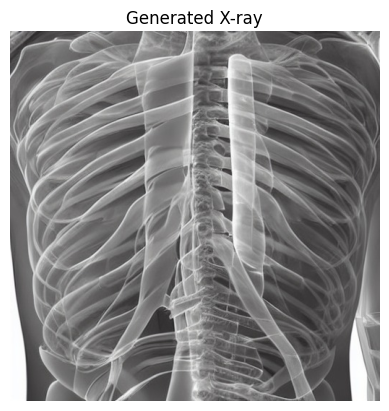

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('assets/9314ae80-1643-4602-a7bc-02653bdc5a9f.jpg')  # your image path
plt.imshow(img)
plt.axis('off')  # Hide axis
plt.title("Generated X-ray")
plt.show()

### Fine Tunning Diffusion Model (Approach3)

In [6]:
# Import necessary libraries
import os
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
from diffusers import (
    DDPMScheduler,
    UNet2DConditionModel,
    AutoencoderKL,
    StableDiffusionPipeline
)
from transformers import CLIPTokenizer, CLIPTextModel
from accelerate import Accelerator
from transformers import get_scheduler
import wandb

In [12]:
# Define paths and parameters
output_dir = "stable-diffusion-xray-finetuned"
model_name = "CompVis/stable-diffusion-v1-4"
batch_size = 4
learning_rate = 1e-5
num_epochs = 2
gradient_accumulation_steps = 1
save_steps = 200
mixed_precision = "fp16"



#### wandb initialization

In [17]:
wandb.init(project="stable_diffusion_training", config={
    "num_epochs": num_epochs,
    "model_name": model_name,
    "output_dir": output_dir,
    "save_steps": save_steps
})


epoch,▁▁▁▁▁▁▁▁▁▁
gradient_norm,▅▃▁▇▄▁▇█▃▆
learning_rate,█▇▇▆▅▅▄▃▂▁
step,▁▂▃▃▄▅▆▆▇█
train_loss,▄▃▁▇▂▁██▄▇
epoch,0
gradient_norm,5224.16699
learning_rate,1e-05
step,100
train_loss,0.12357


#### custom dataset creation


In [8]:
# Create a custom dataset class for X-ray images
from torch.utils.data import Dataset, DataLoader, random_split
class XrayDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=77, image_size=512):
        self.dataframe = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.image_size = image_size
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row['image_path']
        caption = row['caption']

        # Load and preprocess image
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        # Tokenize caption
        text_inputs = self.tokenizer(
            caption,
            padding="max_length",
            max_length=self.max_length,
            truncation=True,
            return_tensors="pt"
        )

        return {
            "pixel_values": image,
            "input_ids": text_inputs.input_ids[0],
            "attention_mask": text_inputs.attention_mask[0]
        }

# Set up the accelerator
accelerator = Accelerator(
    gradient_accumulation_steps=gradient_accumulation_steps,
    mixed_precision=mixed_precision
)

# Load the tokenizer and text encoder
tokenizer = CLIPTokenizer.from_pretrained(model_name, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_name, subfolder="text_encoder")

# Freeze the text encoder parameters
text_encoder.requires_grad_(False)

# Load the UNet and VAE
unet = UNet2DConditionModel.from_pretrained(model_name, subfolder="unet")
vae = AutoencoderKL.from_pretrained(model_name, subfolder="vae")

# Freeze the VAE parameters
vae.requires_grad_(False)

# Create the noise scheduler
noise_scheduler = DDPMScheduler.from_pretrained(model_name, subfolder="scheduler")



full_dataset = XrayDataset(captions, tokenizer)

# Split dataset into training and validation (80% train, 20% validation)
train_size = int(0.90 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create the dataset and dataloader
# train_dataset = XrayDataset(captions, tokenizer)
# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Set up the optimizer
optimizer = torch.optim.AdamW(unet.parameters(), lr=learning_rate)

# Prepare everything with accelerator
unet, optimizer, train_dataloader, val_dataloader, text_encoder = accelerator.prepare(
    unet, optimizer, train_dataloader, val_dataloader, text_encoder
)

# Set up learning rate scheduler
lr_scheduler = get_scheduler(
    "cosine",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=len(train_dataloader) * num_epochs
)

# Move VAE and text encoder to GPU
vae = vae.to(accelerator.device)
text_encoder = text_encoder.to(accelerator.device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [15]:
# !pip install torch-fidelity
# !pip install torcheval
# !pip install openai
# !pip install ftfy regex tqdm
# !pip install git+https://github.com/openai/CLIP.git
# !pip install mlflow

#### training & mlflow tracking

In [18]:
# Played code
from torcheval.metrics import FrechetInceptionDistance # I  # For FID
import clip
import shutil
import mlflow
# Training loop




mlflow.start_run()
mlflow.log_params({
    "num_epochs": num_epochs,
    "model_name": model_name,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "gradient_accumulation_steps": gradient_accumulation_steps,
    "mixed_precision": mixed_precision,
    "save_steps": save_steps
})

global_step = 0
progress_bar = tqdm(range(num_epochs * len(train_dataloader)), desc="Training")


clip_model, clip_preprocess = clip.load("ViT-B/32", device=accelerator.device)
clip_model.eval()

def compute_gradient_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.norm(2).pow(2)
            total_norm += param_norm
    return total_norm.sqrt().item()

# Function to generate sample images
def generate_samples(pipeline, prompt, num_samples=4):
    images = pipeline([prompt] * num_samples, num_inference_steps=50).images
    return images

# Function to compute CLIP score
def compute_clip_score(images, prompt):
    text_inputs = clip.tokenize([prompt]).to(accelerator.device)
    image_inputs = torch.stack([clip_preprocess(img).to(accelerator.device) for img in images])
    with torch.no_grad():
        image_features = clip_model.encode_image(image_inputs)
        text_features = clip_model.encode_text(text_inputs)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    return (image_features @ text_features.T).mean().item()


for epoch in range(num_epochs):
    unet.train()

    for step, batch in enumerate(train_dataloader):
        with accelerator.accumulate(unet):
            # Get input images and tokenized prompts
            pixel_values = batch["pixel_values"].to(accelerator.device)
            input_ids = batch["input_ids"].to(accelerator.device)
            attention_mask = batch["attention_mask"].to(accelerator.device)

            # Encode the text
            with torch.no_grad():
                encoder_hidden_states = text_encoder(input_ids, attention_mask=attention_mask)[0]

            # Prepare the latent space
            latents = vae.encode(pixel_values).latent_dist.sample().detach() * 0.18215

            # Sample noise that we'll add to the latents
            noise = torch.randn_like(latents)
            bsz = latents.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device
            ).long()

            # Add noise to the latents according to the noise magnitude at each timestep
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            # Predict the noise residual
            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

            # Calculate the loss
            loss = F.mse_loss(noise_pred, noise)

            # Backward pass and optimize
            accelerator.backward(loss)
            grad_norm = compute_gradient_norm(unet)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

        # Update progress bar
        progress_bar.update(1)
        global_step += 1

        # Log and save
        if global_step % 10 == 0:
            print(f"Epoch: {epoch}, Step: {global_step}, Loss: {loss.detach().item()}")
            wandb.log({
                "epoch": epoch,
                "step": global_step,
                "train_loss": loss.detach().item(),
                "learning_rate": lr_scheduler.get_last_lr()[0],
                "gradient_norm": grad_norm
            })
            mlflow.log_metric("train_loss", loss.detach().item(), step=global_step)
            mlflow.log_metric("learning_rate", lr_scheduler.get_last_lr()[0], step=global_step)
            mlflow.log_metric("gradient_norm", grad_norm, step=global_step)


        if global_step % 100 == 0:
            # Validation loss
            unet.eval()
            val_loss = 0.0
            with torch.no_grad():
                for val_batch in val_dataloader:
                    pixel_values = val_batch["pixel_values"].to(accelerator.device)
                    input_ids = val_batch["input_ids"].to(accelerator.device)
                    attention_mask = val_batch["attention_mask"].to(accelerator.device)
                    encoder_hidden_states = text_encoder(input_ids, attention_mask=attention_mask)[0]
                    latents = vae.encode(pixel_values).latent_dist.sample().detach() * 0.18215
                    noise = torch.randn_like(latents)
                    timesteps = torch.randint(
                        0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device
                    ).long()
                    noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
                    noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
                    val_loss += F.mse_loss(noise_pred, noise).item()
            val_loss /= len(val_dataloader)
            wandb.log({"val_loss": val_loss})
            mlflow.log_metric("val_loss", val_loss, step=global_step)

            # Generate samples and compute metrics
            pipeline = StableDiffusionPipeline.from_pretrained(
                model_name,
                unet=accelerator.unwrap_model(unet),
                text_encoder=text_encoder,
                tokenizer=tokenizer,
                vae=vae
            ).to(accelerator.device)
            sample_prompt = "An X-ray of a human chest"  # Customized for X-ray dataset
            sample_images = generate_samples(pipeline, sample_prompt)

            # Log sample images
            wandb.log({"samples": [wandb.Image(img) for img in sample_images]})

            # Compute CLIP score
            clip_score = compute_clip_score(sample_images, sample_prompt)
            wandb.log({"clip_score": clip_score})
            mlflow.log_metric("clip_score", clip_score, step=global_step)

            # Compute FID
            temp_dir = os.path.join(output_dir, "temp")
            os.makedirs(temp_dir, exist_ok=True)
            for i, img in enumerate(sample_images):
                img.save(os.path.join(temp_dir, f"gen_{i}.png"))
            try:
                fid = FrechetInceptionDistance()
                fid.update(temp_dir, real=True)  # Update with your real images path
                fid.update(temp_dir, real=False)
                fid_score = fid.compute()
                wandb.log({"fid_score": fid_score})
                mlflow.log_metric("fid_score", fid_score, step=global_step)
            except Exception as e:
                print(f"FID computation failed: {e}")
            finally:
                # Clean up temporary directory
                shutil.rmtree(temp_dir, ignore_errors=True)

            unet.train()

        if global_step % save_steps == 0:
            # Save the model
            accelerator.wait_for_everyone()
            unwrapped_unet = accelerator.unwrap_model(unet)

            pipeline = StableDiffusionPipeline.from_pretrained(
                model_name,
                unet=unwrapped_unet,
                text_encoder=text_encoder,
                tokenizer=tokenizer,
                vae=vae
            )

            save_path = os.path.join(output_dir, f"checkpoint-{global_step}")
            pipeline.save_pretrained(save_path)
            print(f"Saved model to {save_path}")
            wandb.log({"checkpoint_saved": save_path})
            mlflow.log_artifact(save_path)



Training:   0%|          | 0/2438 [00:00<?, ?it/s]

Epoch: 0, Step: 10, Loss: 0.07741336524486542
Epoch: 0, Step: 20, Loss: 0.13438326120376587
Epoch: 0, Step: 30, Loss: 0.06757290661334991
Epoch: 0, Step: 40, Loss: 0.07078693807125092
Epoch: 0, Step: 50, Loss: 0.0762188732624054
Epoch: 0, Step: 60, Loss: 0.07127632200717926
Epoch: 0, Step: 70, Loss: 0.20239025354385376
Epoch: 0, Step: 80, Loss: 0.10523304343223572
Epoch: 0, Step: 90, Loss: 0.0871240496635437
Epoch: 0, Step: 100, Loss: 0.09491331875324249


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

FID computation failed: FrechetInceptionDistance.update() got an unexpected keyword argument 'real'
Epoch: 0, Step: 110, Loss: 0.24115082621574402
Epoch: 0, Step: 120, Loss: 0.09335313737392426
Epoch: 0, Step: 130, Loss: 0.12835952639579773
Epoch: 0, Step: 140, Loss: 0.09114790707826614
Epoch: 0, Step: 150, Loss: 0.0747048407793045
Epoch: 0, Step: 160, Loss: 0.08346015214920044
Epoch: 0, Step: 170, Loss: 0.1775645613670349
Epoch: 0, Step: 180, Loss: 0.1252739429473877
Epoch: 0, Step: 190, Loss: 0.18883739411830902
Epoch: 0, Step: 200, Loss: 0.0336654856801033


...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

FID computation failed: FrechetInceptionDistance.update() got an unexpected keyword argument 'real'


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Saved model to stable-diffusion-xray-finetuned/checkpoint-2400
Epoch: 1, Step: 2410, Loss: 0.04447094723582268
Epoch: 1, Step: 2420, Loss: 0.040794312953948975
Epoch: 1, Step: 2430, Loss: 0.17096830904483795


### inference

In [40]:
# Function to generate X-ray images from text
def generate_xray_from_text(
    prompt,
    model_path="stable-diffusion-xray-finetuned/checkpoint-1200", # change this ?
    height=512,
    width=512,
    num_inference_steps=50,
    guidance_scale=7.5,
    negative_prompt=None,
    output_file=None
):
    """
    Generate an X-ray image from a text prompt using a fine-tuned Stable Diffusion model.

    Args:
        prompt (str): Text description of the X-ray image to generate
        model_path (str): Path to the fine-tuned model checkpoint
        height (int): Height of output image
        width (int): Width of output image
        num_inference_steps (int): Number of denoising steps
        guidance_scale (float): Scale for classifier-free guidance
        negative_prompt (str, optional): Negative prompt to guide generation
        output_file (str, optional): Path to save the generated image

    Returns:
        PIL.Image: Generated X-ray image
    """
    # Load the fine-tuned pipeline
    pipeline = StableDiffusionPipeline.from_pretrained(
        model_path,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
    )

    # Move to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    pipeline = pipeline.to(device)

    # Generate the image
    with torch.no_grad():
        image = pipeline(
            prompt=prompt,
            height=height,
            width=width,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            negative_prompt=negative_prompt
        ).images[0]

    # Save the image if output path is provided
    if output_file:
        image.save(output_file)
        print(f"Image saved to {output_file}")

    return image

In [30]:
# Example usage
if __name__ == "__main__":
    # After training, generate a sample image
    prompt = "Chest X-ray showing pneumonia in the right lower lobe"
    generate_xray_from_text(
        prompt=prompt,
        output_file="generated_pneumonia_xray.png"
    )

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Image saved to generated_pneumonia_xray.png


In [42]:
# Example usage
if __name__ == "__main__":
    # After training, generate a sample image
    prompt = "X-ray of the hand showing rheumatoid arthritis"
    generate_xray_from_text(
        prompt=prompt,
        output_file="generated_pneumonia_xray3.png"
    )

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Image saved to generated_pneumonia_xray3.png


### gradio inference function

In [37]:
import gradio as gr

def gradio_generate_xray(prompt, negative_prompt, height, width, num_inference_steps, guidance_scale, model_path, output_file):
    """
    Wrapper function for Gradio to call generate_xray_from_text and return the image and save message.
    """
    # Ensure height and width are multiples of 8 (required by Stable Diffusion)
    height = int(height // 8 * 8)
    width = int(width // 8 * 8)

    # Call the inference function
    image = generate_xray_from_text(
        prompt=prompt,
        model_path=model_path,
        height=height,
        width=width,
        num_inference_steps=int(num_inference_steps),
        guidance_scale=guidance_scale,
        negative_prompt=negative_prompt if negative_prompt else None,
        output_file=output_file if output_file else None
    )

    # Return the image and a message
    save_message = f"Image saved to {output_file}" if output_file else "Image not saved (no output file specified)"
    return image, save_message

# Create Gradio interface
iface = gr.Interface(
    fn=gradio_generate_xray,
    inputs=[
        gr.Textbox(label="Prompt", value="An X-ray of a human chest", placeholder="Enter text description for the X-ray image"),
        gr.Textbox(label="Negative Prompt (optional)", placeholder="Enter negative prompt (e.g., blurry, low quality)"),
        gr.Slider(label="Height", minimum=256, maximum=1024, step=8, value=512),
        gr.Slider(label="Width", minimum=256, maximum=1024, step=8, value=512),
        gr.Slider(label="Number of Inference Steps", minimum=10, maximum=100, step=1, value=50),
        gr.Slider(label="Guidance Scale", minimum=1.0, maximum=20.0, step=0.5, value=7.5),
        gr.Textbox(label="Model Path", value="stable-diffusion-xray-finetuned/checkpoint-1200", placeholder="Path to model checkpoint"),
        gr.Textbox(label="Output File (optional)", placeholder="Enter path to save image (e.g., generated_xray.png)")
    ],
    outputs=[
        gr.Image(label="Generated X-ray Image"),
        gr.Text(label="Save Status")
    ],
    title="X-ray Image Generator",
    description="Generate X-ray images from text prompts using a fine-tuned Stable Diffusion model.",
    theme="default"
)

# Launch the interface
if __name__ == "__main__":
    iface.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ae42014b023b91b224.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
